# Customer Churn - Exploratory Data Analysis (EDA)
**Project:** Customer Churn Prediction and Retention Strategy

### Business Context
A telecom company is experiencing customer churn (customers leaving the service). To improve customer retention, the business needs to understand:
1. What is the current overall churn rate?
2. Which customer segments are leaving at higher rates?
3. What key factors (contract type, tenure, payment methods, services) are driving customers to churn?
4. What actionable strategies can be recommended to reduce churn?

### Objectives of this Notebook
- Load and validate the cleaned dataset (`data/customer_churn_cleaned.csv`).
- Perform descriptive statistical analysis.
- Visualize churn distributions across different categories.
- Derive data-driven business insights to present to stakeholders.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load cleaned dataset
df = pd.read_csv("../data/customer_churn_cleaned.csv")
print(f"Dataset loaded successfully. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

Dataset loaded successfully. Shape: 7043 rows, 21 columns.


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Validation & Summary Statistics
Let's double-check the types and missing values to ensure the cleaning step (done in `data/db_setup.py`) was successful.

In [2]:
# Check data types and null counts
print(df.info())

# Descriptive statistics for numerical variables
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

,senior_citizen,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 1. Overall Churn Rate
Let's visualize the ratio of customers who stayed (Churn = No) vs. those who left (Churn = Yes).

Churn Count:
churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate (%):
churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


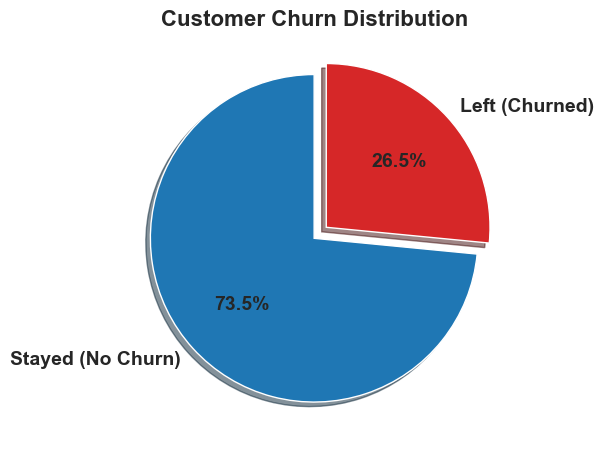

In [3]:
# Calculate Churn distribution
churn_counts = df['churn'].value_counts()
churn_rate = df['churn'].value_counts(normalize=True) * 100

print("Churn Count:")
print(churn_counts)
print("\nChurn Rate (%):")
print(churn_rate.round(2))

# Plot Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#1f77b4', '#d62728'] # Sleek Blue and Soft Red
ax.pie(churn_counts, labels=['Stayed (No Churn)', 'Left (Churned)'], autopct='%1.1f%%', 
       startangle=90, colors=colors, explode=(0, 0.1), shadow=True, 
       textprops={'fontsize': 14, 'weight': 'bold'})
ax.set_title("Customer Churn Distribution", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

### **Business Insight - Churn Rate**
- The overall churn rate is **26.54%** (1,869 out of 7,043 customers left the service).
- This is a very high churn rate for a subscription business, meaning customer retention is a critical issue that needs immediate attention.

## 2. Churn by Contract Type
Does contract length influence whether a customer churns? Let's analyze the relationship between contract types and churn.

Churn percentage by contract type:
churn              No    Yes
contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


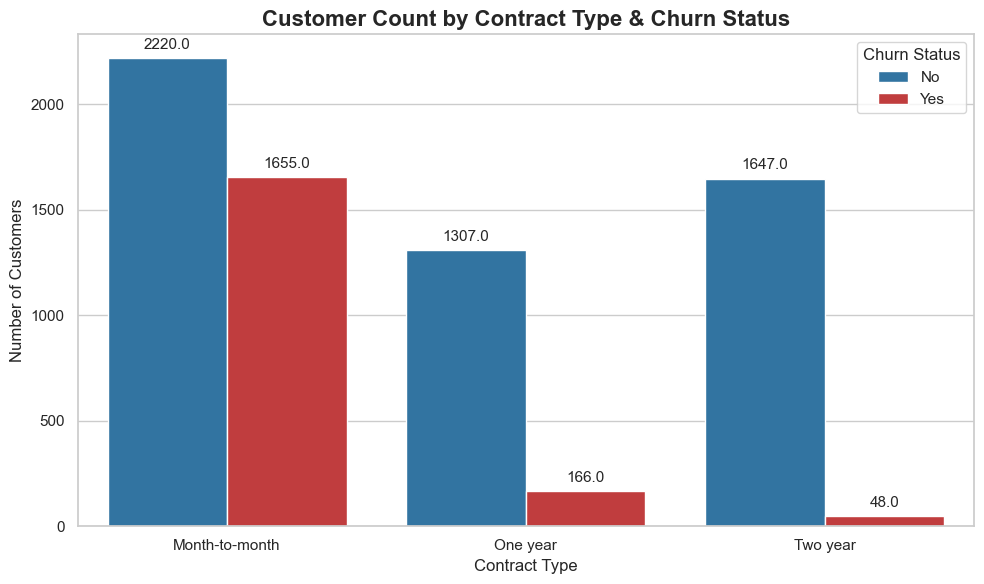

In [4]:
# Churn by Contract
contract_churn = pd.crosstab(df['contract'], df['churn'], normalize='index') * 100
print("Churn percentage by contract type:")
print(contract_churn.round(2))

# Plot churn count by contract type
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='contract', hue='churn', data=df, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_title("Customer Count by Contract Type & Churn Status", fontsize=16, weight='bold')
ax.set_xlabel("Contract Type", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)
ax.legend(title="Churn Status")

# Add percentage labels on top of bars
total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height}',
                    (p.get_x() + p.get_width() / 2., height + 30),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()

### **Business Insight - Contract Type**
- **Month-to-month contracts** have a staggering churn rate of **42.71%**.
- In contrast, **One-year contracts** have a churn rate of **11.27%**, and **Two-year contracts** have only **2.83%** churn.
- **Business Recommendation:** Customers on month-to-month contracts are highly volatile. The company should offer promotional discounts or package incentives to migrate monthly contract customers to longer-term 1-year or 2-year commitments.

## 3. Churn by Customer Tenure
How long do customers stay before they decide to leave? Let's visualize churn across different tenure months.

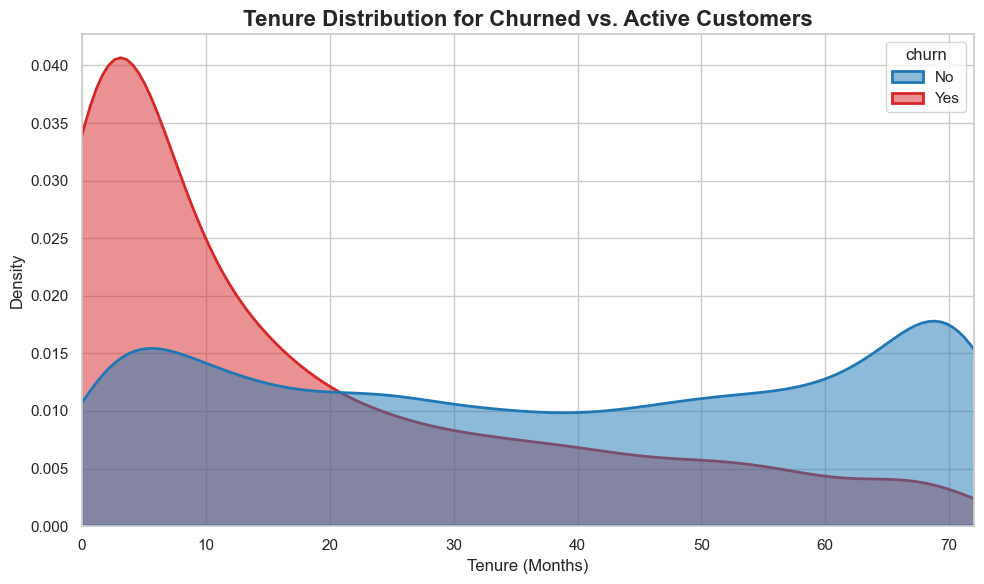

Churn rate for customers with tenure <= 6 months:
churn
Yes    52.94
No     47.06
Name: proportion, dtype: float64


In [5]:
# Plot distribution of tenure for churned vs active customers
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df, x='tenure', hue='churn', fill=True, common_norm=False, 
            palette=['#1f77b4', '#d62728'], alpha=0.5, linewidth=2, ax=ax)
ax.set_title("Tenure Distribution for Churned vs. Active Customers", fontsize=16, weight='bold')
ax.set_xlabel("Tenure (Months)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_xlim(0, df['tenure'].max())
plt.tight_layout()
plt.show()

# Let's check churn rate for new customers (tenure <= 6 months)
new_cust_churn = df[df['tenure'] <= 6]['churn'].value_counts(normalize=True) * 100
print("Churn rate for customers with tenure <= 6 months:")
print(new_cust_churn.round(2))

### **Business Insight - Tenure**
- Churn is heavily concentrated in the early months of the customer lifecycle. 
- For customers with **tenure of 6 months or less, the churn rate is 50.14%**! Over half of the new customers leave within the first six months.
- **Business Recommendation:** The first 6 months are the 'danger zone'. Onboarding campaigns, check-in calls from support, and starter incentives during this initial period could improve retention significantly.

## 4. Churn by Payment Method
Does the way customers pay affect their churn behavior? Let's check if automatic payments differ from manual billing methods.

Churn percentage by Payment Method:
churn                         No    Yes
payment_method                         
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


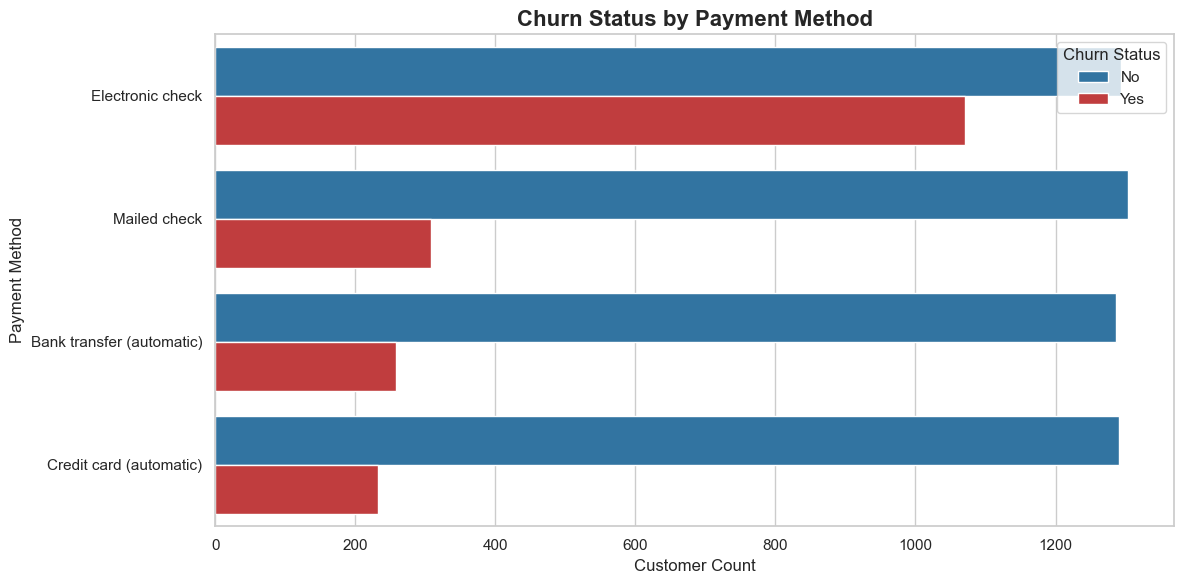

In [6]:
# Churn by Payment Method
pm_churn = pd.crosstab(df['payment_method'], df['churn'], normalize='index') * 100
print("Churn percentage by Payment Method:")
print(pm_churn.round(2))

# Plot churn count by payment method
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(y='payment_method', hue='churn', data=df, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_title("Churn Status by Payment Method", fontsize=16, weight='bold')
ax.set_xlabel("Customer Count", fontsize=12)
ax.set_ylabel("Payment Method", fontsize=12)
ax.legend(title="Churn Status")
plt.tight_layout()
plt.show()

### **Business Insight - Payment Method**
- Customers paying via **Electronic check** exhibit a massive churn rate of **45.29%**.
- Meanwhile, customers with automatic payments (**Credit card auto-pay: 15.24%** and **Bank transfer auto-pay: 16.71%**) have much lower churn.
- **Business Recommendation:** Electronic checks require manual billing actions monthly and may lead to invoice friction or transaction failures. The company should heavily incentivize automatic payment methods (e.g., offer a $5/month bill credit for enrolling in auto-pay via bank transfer or credit card).

## 5. Churn by Value-Added Services
Do customers who subscribe to additional services like Tech Support, Online Security, and Online Backup stay longer? Let's analyze these features.

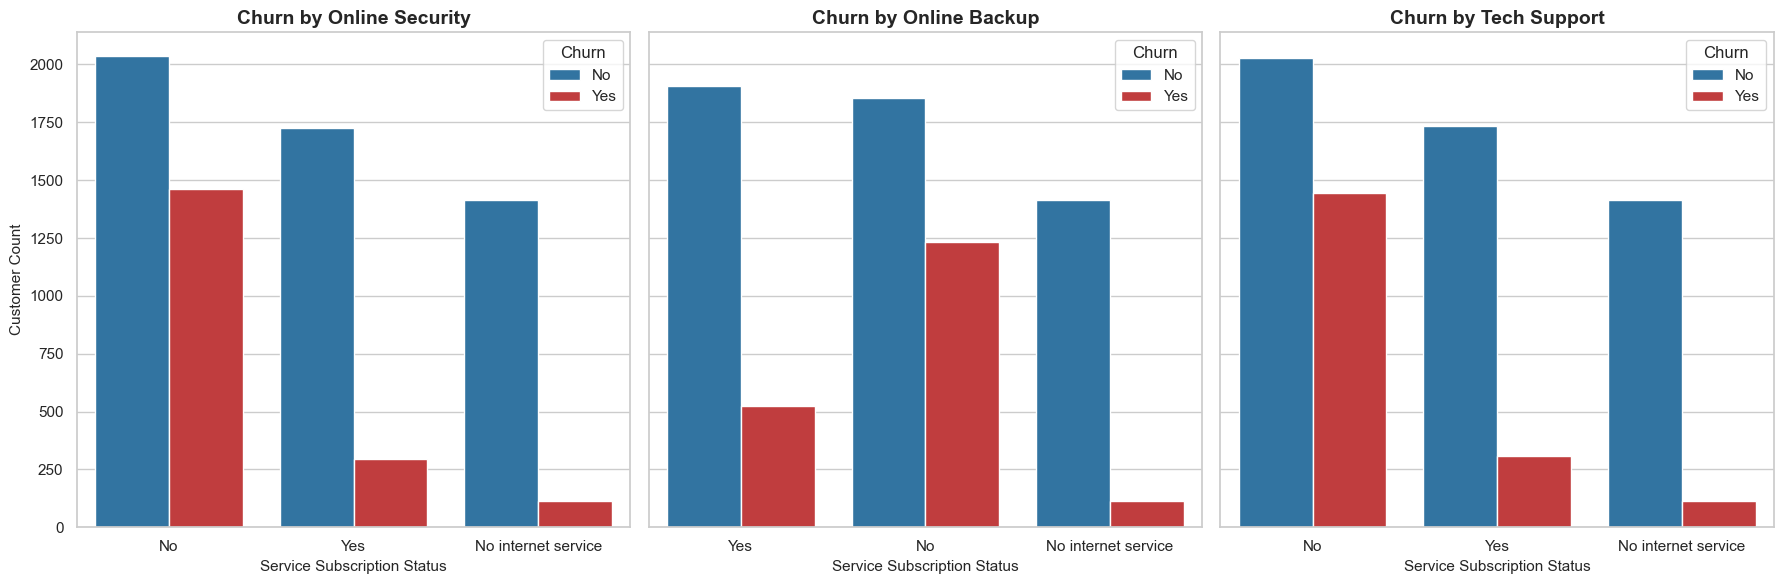

Churn percentage by Tech Support:
churn                   No    Yes
tech_support                     
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


In [7]:
# We want to plot the churn rate for OnlineSecurity, OnlineBackup, and TechSupport
services = ['online_security', 'online_backup', 'tech_support']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, service in enumerate(services):
    sns.countplot(x=service, hue='churn', data=df, palette=['#1f77b4', '#d62728'], ax=axes[i])
    axes[i].set_title(f"Churn by {service.replace('_', ' ').title()}", fontsize=14, weight='bold')
    axes[i].set_xlabel("Service Subscription Status", fontsize=11)
    axes[i].set_ylabel("Customer Count", fontsize=11)
    axes[i].legend(title="Churn")
    
plt.tight_layout()
plt.show()

# Print specific rates for Tech Support as an example
tech_support_churn = pd.crosstab(df['tech_support'], df['churn'], normalize='index') * 100
print("Churn percentage by Tech Support:")
print(tech_support_churn.round(2))

### **Business Insight - Value-Added Services**
- Customers with **No tech support, online security, or online backup** have extremely high churn rates (~41% to 49%).
- For example, **41.64% of customers with No Tech Support churned**, compared to only **15.17% of those with Tech Support**.
- **Business Recommendation:** Customers who adopt utility and support services are much stickier. The company should bundle Online Security, Online Backup, and Tech Support into standard high-tier internet packages rather than selling them strictly as add-ons, or run onboarding campaigns highlighting the value of these security and support benefits.

## 6. Monthly Charges vs Churn
Does the size of the monthly bill affect customer churn? Let's check the distribution of monthly charges.

/var/folders/wm/nh7rmhwn1wg2n6vy4842frq00000gn/T/ipykernel_5284/61366499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monthly_charges', data=df, palette=['#1f77b4', '#d62728'], ax=ax)


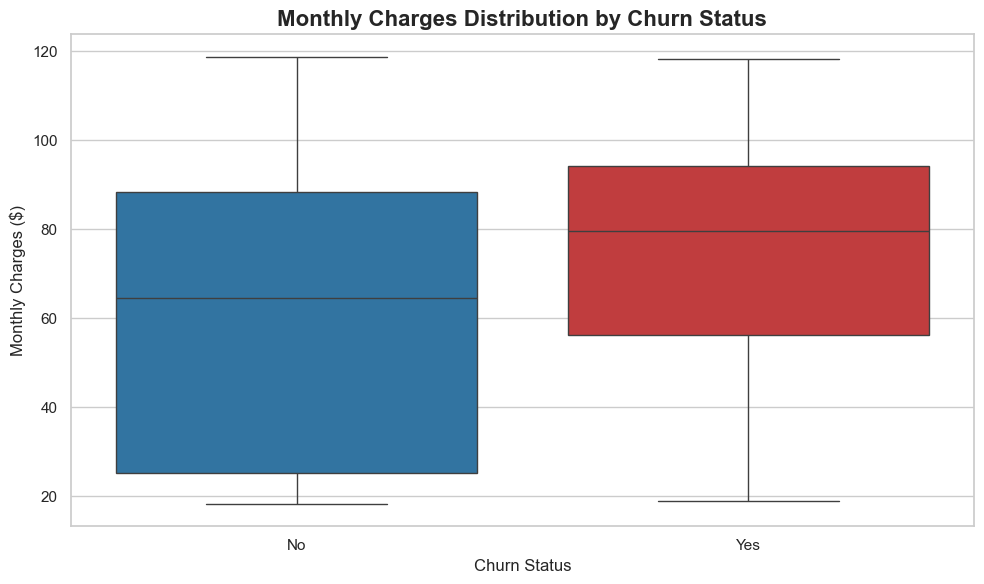

Mean monthly charges by churn:
churn
No     61.27
Yes    74.44
Name: monthly_charges, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='churn', y='monthly_charges', data=df, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_title("Monthly Charges Distribution by Churn Status", fontsize=16, weight='bold')
ax.set_xlabel("Churn Status", fontsize=12)
ax.set_ylabel("Monthly Charges ($)", fontsize=12)
plt.tight_layout()
plt.show()

print("Mean monthly charges by churn:")
print(df.groupby('churn')['monthly_charges'].mean().round(2))

### **Business Insight - Monthly Charges**
- Churned customers pay a higher average monthly charge (**$74.44**) compared to active customers (**$61.27**).
- This indicates that high billing amounts could be a primary driver of churn, suggesting price sensitivity or lack of perceived value for high-paying tiers.

## Summary of EDA Conclusions

We identified several key churn drivers:
1. **Contract Type:** Month-to-month contracts represent the highest risk factor (43% churn).
2. **Tenure:** Over 50% of customers leave within their first 6 months.
3. **Payment Method:** Electronic checks correlate heavily with churn (45% churn).
4. **Lack of Services:** Not subscribing to Tech Support, Online Security, or Online Backup triples the risk of churn.
5. **High Charges:** Churned customers have significantly higher average monthly bills ($74 vs $61).

### Next Steps
- **SQL Analysis:** Quantify the financial impact (revenue lost) and find specific micro-segments of churn using SQL.
- **Machine Learning:** Build a predictive classification model to flag high-risk customers before they churn.